# Alpha Combination: Dynamic Alpha Risk, MVO, and Execution

## How to use
Inputs expected from `notebooks/alpha_combination.ipynb`:
- `alpha_returns_df` (date x alpha)
- `all_weights` (`{alpha_name: date x instrument weights}`)

Optional inputs:
- `fwd_returns` or `data['close_df']` for forward instrument returns
- `sector_exposure` (instrument x sector exposures)
- `adv_df` (date x instrument ADV or Series by instrument)

Run cells top-to-bottom:
1. Imports + hyperparameters
2. Function library (`estimate_sigma_ewma`, `estimate_C_shrunk`, `build_Sigma_alpha`, `estimate_mu`, `solve_alpha_mvo`, `combine_alphas_to_weights`, `solve_tracking_qp`)
3. End-to-end run (steps 2-6)
4. Validation + diagnostics


Loaded 18 alpha functions from Factors.ipynb.
Loaded 14 input dataframes from c:\Users\danie\Python\CapitOx\Multi-Factor-Equities-Investing\notebooks\data\alpha_inputs.


c:\Users\danie\Python\CapitOx\Multi-Factor-Equities-Investing\notebooks\operators_library.py:140: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cond = cond_df.reindex(val_df.index).fillna(False).astype(bool)
c:\Users\danie\Python\CapitOx\Multi-Factor-Equities-Investing\notebooks\operators_library.py:140: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cond = cond_df.reindex(val_df.index).fillna(False).astype(bool)


Built alpha dictionary with 18 alphas.
['alpha_0413a', 'alpha_0615a', 'alpha_0403c', 'alpha_0812a', 'alpha_0407a', 'alpha_0612d', 'alpha_0503b', 'alpha_0412', 'alpha_0418b', 'alpha_0505', 'alpha_0404b', 'alpha_0618e', 'alpha_0413b', 'alpha_0810a', 'alpha_0415b', 'alpha_0617a', 'alpha_0604c', 'alpha_0616a']


C:\Users\danie\AppData\Local\Temp\ipykernel_43760\543741967.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  fwd_returns = data['close_df'].pct_change().shift(-1)


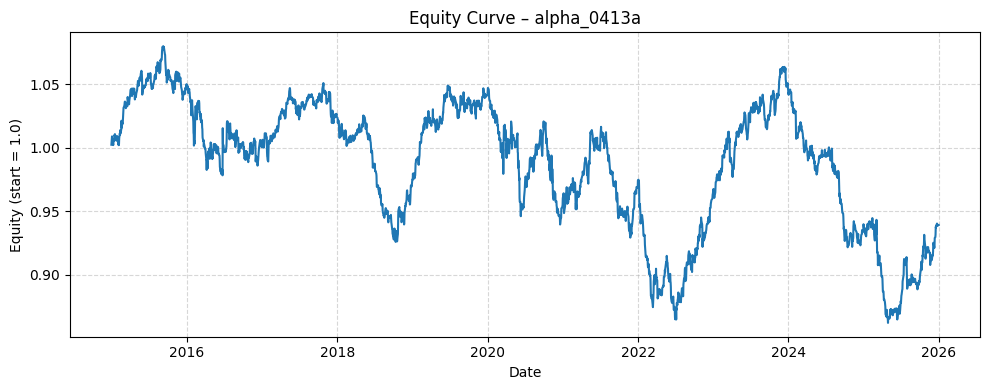

===== Performance Summary =====
Periods             : 2817
Total Return        :   -6.07%
CAGR                :   -0.56%
Ann. Volatility     :    5.66%
Sharpe Ratio        :    -0.10
Max Drawdown        :  -20.18%
Calmar Ratio        :    -0.03
Hit Rate (p>0)      :   50.76%


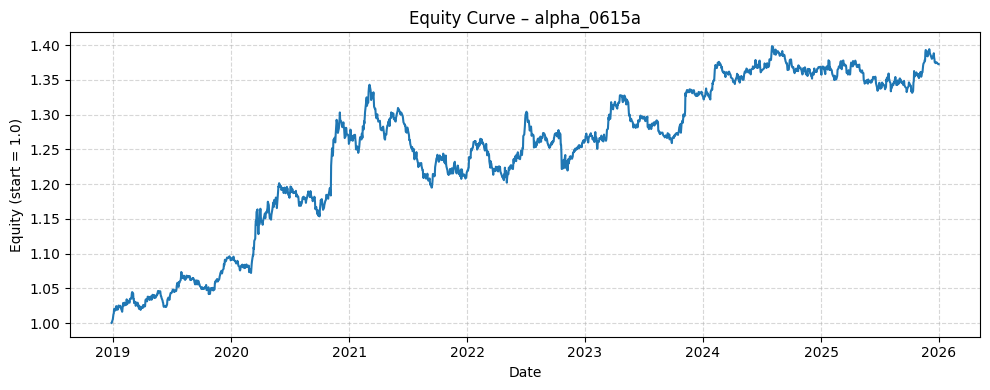

===== Performance Summary =====
Periods             : 1796
Total Return        :   37.25%
CAGR                :    4.54%
Ann. Volatility     :    6.04%
Sharpe Ratio        :     0.75
Max Drawdown        :  -11.02%
Calmar Ratio        :     0.41
Hit Rate (p>0)      :   50.45%


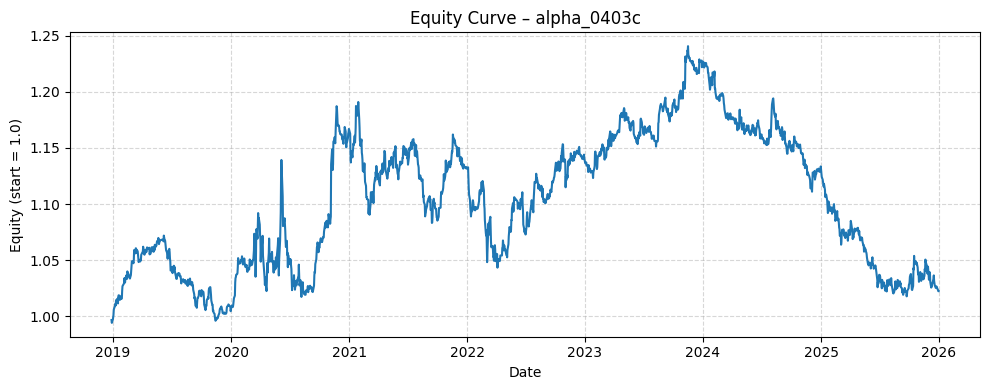

===== Performance Summary =====
Periods             : 1796
Total Return        :    2.23%
CAGR                :    0.31%
Ann. Volatility     :    7.34%
Sharpe Ratio        :     0.04
Max Drawdown        :  -17.98%
Calmar Ratio        :     0.02
Hit Rate (p>0)      :   49.78%


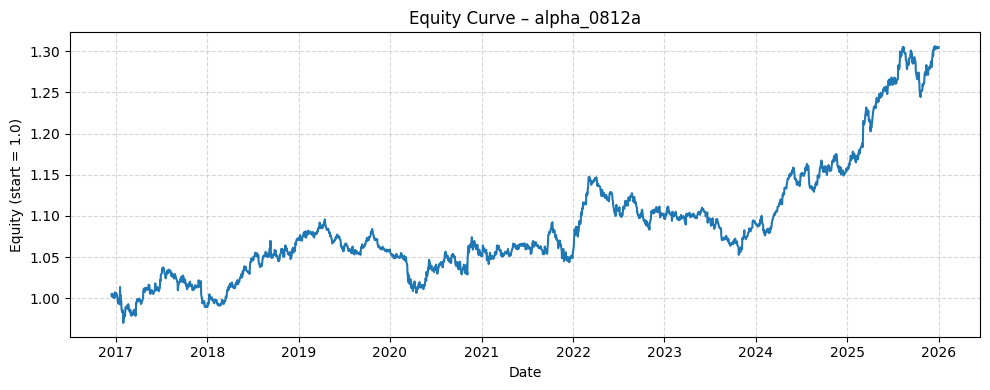

===== Performance Summary =====
Periods             : 2314
Total Return        :   30.41%
CAGR                :    2.93%
Ann. Volatility     :    4.54%
Sharpe Ratio        :     0.65
Max Drawdown        :   -8.26%
Calmar Ratio        :     0.35
Hit Rate (p>0)      :   51.30%


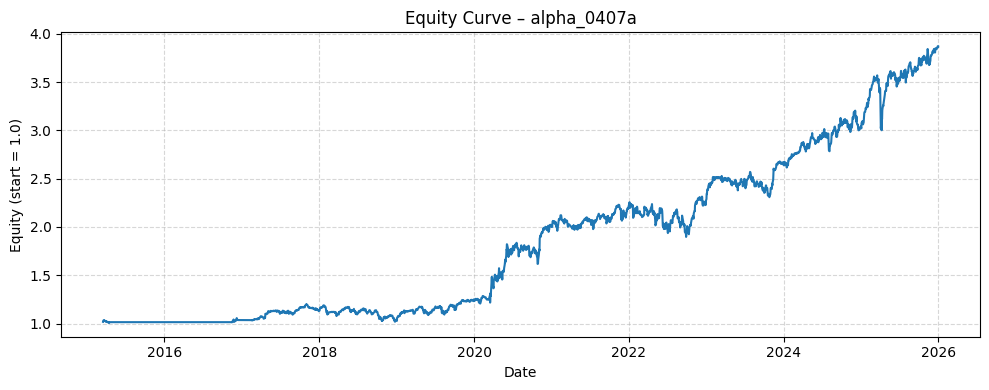

===== Performance Summary =====
Periods             : 2764
Total Return        :  286.76%
CAGR                :   13.12%
Ann. Volatility     :   14.38%
Sharpe Ratio        :     0.91
Max Drawdown        :  -15.92%
Calmar Ratio        :     0.82
Hit Rate (p>0)      :   45.55%


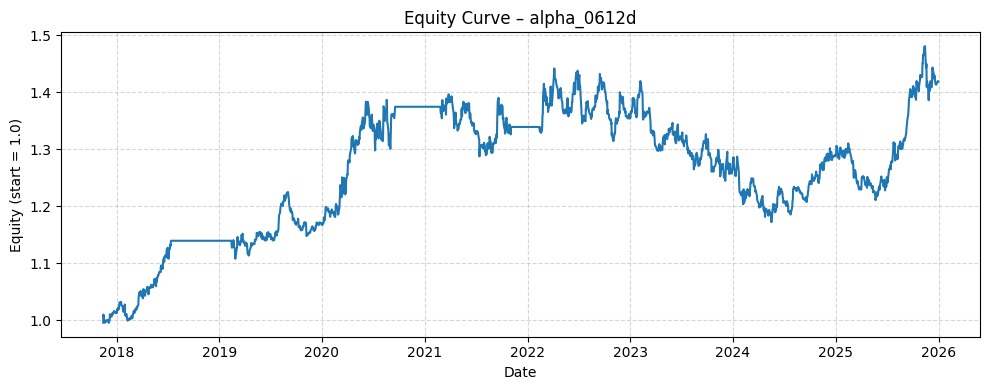

===== Performance Summary =====
Periods             : 2080
Total Return        :   41.87%
CAGR                :    4.33%
Ann. Volatility     :    8.62%
Sharpe Ratio        :     0.50
Max Drawdown        :  -18.71%
Calmar Ratio        :     0.23
Hit Rate (p>0)      :   42.84%


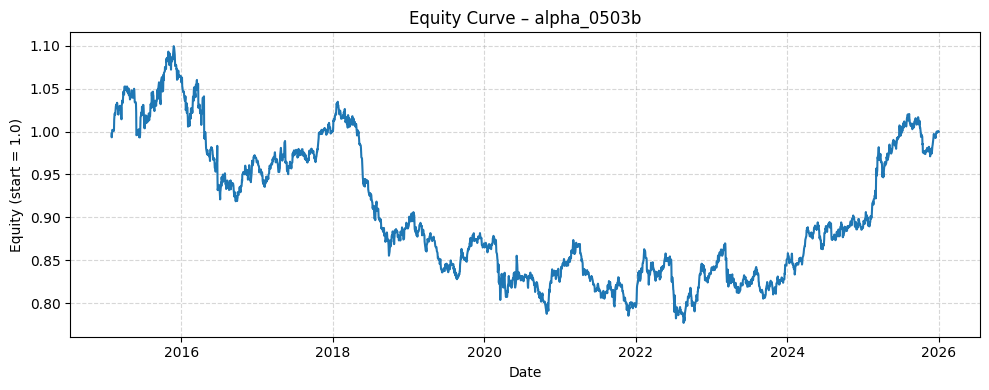

===== Performance Summary =====
Periods             : 2811
Total Return        :   -0.04%
CAGR                :   -0.00%
Ann. Volatility     :    7.24%
Sharpe Ratio        :    -0.00
Max Drawdown        :  -29.36%
Calmar Ratio        :    -0.00
Hit Rate (p>0)      :   50.02%


In [7]:
%run "./alpha_combination.ipynb"

In [8]:
import warnings
from typing import Any, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cvxpy as cp
    HAS_CVXPY = True
except Exception:
    HAS_CVXPY = False

pd.set_option("display.width", 140)

DEFAULTS = {
    "periods_per_year": 252,
    "sigma_halflife": 20,
    "sigma_min_periods": 20,
    "corr_refresh": "M",
    "corr_shrink": 0.20,
    "corr_lookback": 252,
    "corr_min_periods": 60,
    "mu_method": "ir_sigma",  # ir_sigma | zero | ewm_shrunk
    "mu_params": {
        "ir_shrink": 0.70,
        "ir_cap": 2.0,
        "ir_window": None,
        "halflife": 63,
        "mean_shrink": 0.85,
    },
    "lambda_risk": 10.0,
    "nu_ridge": 1e-3,
    "turnover_gamma": 1.0,
    "alpha_constraints": {
        "budget": 1.0,      # set to None for unconstrained budget
        "long_only": False,
        "leverage_max": None,
        "box": None,
    },
    "omega_method": "diag_ewma",  # diag_ewma | ewma_full
    "omega_halflife": 20,
    "omega_lookback": 126,
    "omega_min_periods": 40,
    "omega_shrink": 0.10,
    "tracking_costs": {
        "model": "l2",    # l2 | lin_quad
        "eta": 50.0,
        "c1": 1e-4,
        "c2": 50.0,
    },
    "tracking_constraints": {
        "gross_max": 1.5,
        "net_target": 0.0,
        "net_band": 0.00,
        "position_limit": 0.05,
        "sector_band": 0.00,
        "adv_participation": None,
        "aum": 1.0,
    },
}

if "alpha_returns_df" not in globals() or "all_weights" not in globals():
    raise ValueError("Expected `alpha_returns_df` and `all_weights` in memory from alpha_combination notebook.")

R_alpha = alpha_returns_df.copy().sort_index().astype(float)
if not isinstance(R_alpha.index, pd.DatetimeIndex):
    R_alpha.index = pd.to_datetime(R_alpha.index)

if "fwd_returns" in globals():
    instrument_fwd_returns = fwd_returns.copy().sort_index().astype(float)
elif "data" in globals() and isinstance(data, dict) and "close_df" in data:
    instrument_fwd_returns = data["close_df"].pct_change().shift(-1).iloc[:-1, :].sort_index().astype(float)
else:
    instrument_fwd_returns = None
    warnings.warn("No `fwd_returns` or `data['close_df']` found. Some diagnostics will be limited.")

shared_alphas = [k for k in R_alpha.columns if k in all_weights]
if not shared_alphas:
    raise ValueError("No overlap between alpha_returns_df columns and all_weights keys.")

R_alpha = R_alpha[shared_alphas]
all_weights = {k: all_weights[k].copy() for k in shared_alphas}

# Avoid lookahead: alpha_returns_df[t] is return from t->t+1, so use lagged returns for estimation.
R_info = R_alpha.shift(1)

print("cvxpy available:", HAS_CVXPY)
print("R_alpha shape:", R_alpha.shape)
if instrument_fwd_returns is not None:
    print("instrument_fwd_returns shape:", instrument_fwd_returns.shape)


cvxpy available: True
R_alpha shape: (2832, 18)
instrument_fwd_returns shape: (2816, 50)


In [9]:
R_alpha

,alpha_0413a,alpha_0615a,alpha_0403c,alpha_0812a,alpha_0407a,alpha_0612d,alpha_0503b,alpha_0412,alpha_0418b,alpha_0505,alpha_0404b,alpha_0618e,alpha_0413b,alpha_0810a,alpha_0415b,alpha_0617a,alpha_0604c,alpha_0616a
Date,,,,,,,,,,,,,,,,,,
2014-12-30,0.002422,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000
2015-01-01,NaN,NaN,0.000000,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,NaN,0.000000
2015-01-02,0.006572,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005026,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2015-01-05,-0.004594,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.001056,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2015-01-06,0.000174,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.001754,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23,0.000865,0.000302,-0.000073,0.000174,-0.000160,-0.000335,-0.001156,0.000298,0.000039,0.000436,-0.000023,0.000893,-0.000045,-0.000212,-0.000250,0.000237,-0.000395,-0.000385
2025-12-24,-0.001951,0.000683,0.001415,-0.001905,0.001314,0.000023,-0.000301,-0.000539,0.001509,0.001920,0.000703,0.000221,0.001771,-0.000158,-0.001099,-0.000399,-0.003144,0.002243
2025-12-29,0.000500,-0.001661,-0.003269,0.001524,0.006967,0.004269,0.001957,-0.000085,-0.001469,-0.002549,-0.001427,0.000937,0.000676,-0.000914,-0.000805,0.000133,0.001557,-0.000470


In [10]:
def ensure_psd(A: np.ndarray, min_eig: float = 1e-8) -> np.ndarray:
    """Project symmetric matrix to PSD via eigenvalue clipping."""
    A = np.asarray(A, dtype=float)
    A = np.nan_to_num(A, nan=0.0, posinf=0.0, neginf=0.0)
    A = 0.5 * (A + A.T)
    vals, vecs = np.linalg.eigh(A)
    vals = np.clip(vals, min_eig, None)
    out = (vecs * vals) @ vecs.T
    return 0.5 * (out + out.T)


def matrix_cond(A: np.ndarray, eps: float = 1e-12) -> float:
    vals = np.linalg.eigvalsh(0.5 * (A + A.T))
    vals = vals[vals > eps]
    if len(vals) == 0:
        return float("inf")
    return float(vals.max() / vals.min())


def estimate_sigma_ewma(R: pd.DataFrame, halflife: float, min_periods: int = 20, eps: float = 1e-8) -> pd.DataFrame:
    """EWMA conditional volatility per alpha."""
    mu = R.ewm(halflife=halflife, adjust=False, min_periods=min_periods).mean()
    var = (R - mu).pow(2).ewm(halflife=halflife, adjust=False, min_periods=min_periods).mean()
    sigma = np.sqrt(var.clip(lower=eps)).ffill()
    fallback = R.std(ddof=0).replace(0.0, np.nan).fillna(1.0)
    return sigma.fillna(fallback).clip(lower=eps)


def estimate_C_shrunk(
    R_scaled: pd.DataFrame,
    refresh: str = "M",
    shrink: float = 0.2,
    lookback: Optional[int] = 252,
    min_periods: int = 60,
    eps: float = 1e-6,
) -> Tuple[Dict[pd.Timestamp, np.ndarray], pd.DataFrame]:
    """
    Correlation of vol-normalized returns with shrinkage to identity.
    Refresh schedule can be monthly (`refresh='M'`) while sigma updates daily.
    """
    if not isinstance(R_scaled.index, pd.DatetimeIndex):
        raise TypeError("R_scaled index must be DatetimeIndex.")

    cols = R_scaled.columns
    n = len(cols)
    I = np.eye(n)
    C_cur = I.copy()
    C_by_date: Dict[pd.Timestamp, np.ndarray] = {}
    diag_rows = []
    last_bucket = None

    for t, dt in enumerate(R_scaled.index):
        bucket = dt.to_period(refresh)
        if bucket != last_bucket:
            hist = R_scaled.iloc[: t + 1] if lookback is None else R_scaled.iloc[max(0, t - lookback + 1): t + 1]
            hist = hist.replace([np.inf, -np.inf], np.nan).dropna(how="all")
            if len(hist) >= min_periods:
                corr = hist.corr(min_periods=max(3, min_periods // 3)).reindex(index=cols, columns=cols).to_numpy(dtype=float)
                corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
                np.fill_diagonal(corr, 1.0)
                corr = 0.5 * (corr + corr.T)

                C = (1.0 - shrink) * corr + shrink * I
                C = ensure_psd(C, min_eig=eps)

                # Renormalize to correlation form
                d = np.sqrt(np.diag(C))
                d = np.where(d > eps, d, 1.0)
                C = C / np.outer(d, d)
                np.fill_diagonal(C, 1.0)
                C_cur = ensure_psd(C, min_eig=eps)

        C_by_date[dt] = C_cur.copy()
        avg_corr = float((C_cur.sum() - np.trace(C_cur)) / (n * (n - 1))) if n > 1 else 0.0
        diag_rows.append((dt, avg_corr, matrix_cond(C_cur)))
        last_bucket = bucket

    C_diag = pd.DataFrame(diag_rows, columns=["date", "avg_corr", "cond_C"]).set_index("date")
    return C_by_date, C_diag


def build_Sigma_alpha(sigma: pd.DataFrame, C_by_date: Dict[pd.Timestamp, np.ndarray], eps: float = 1e-8) -> Tuple[Dict[pd.Timestamp, np.ndarray], pd.DataFrame]:
    """Build Sigma_alpha,t = V_t @ C_t @ V_t and enforce PSD."""
    k = sigma.shape[1]
    I = np.eye(k)
    out: Dict[pd.Timestamp, np.ndarray] = {}
    rows = []

    for dt in sigma.index:
        s = sigma.loc[dt].to_numpy(dtype=float)
        finite = np.isfinite(s)
        if not finite.all():
            fill = np.nanmedian(s[finite]) if finite.any() else 1.0
            s = np.where(finite, s, fill)
        s = np.where(s > eps, s, eps)

        C_t = C_by_date.get(dt, I)
        S_t = np.diag(s) @ C_t @ np.diag(s)
        S_t = ensure_psd(S_t, min_eig=eps)
        out[dt] = S_t
        rows.append((dt, float(np.mean(s)), float(np.median(s)), matrix_cond(S_t)))

    diag = pd.DataFrame(rows, columns=["date", "mean_sigma", "median_sigma", "cond_Sigma"]).set_index("date")
    return out, diag


def estimate_mu(
    R: pd.DataFrame,
    sigma: pd.DataFrame,
    method: str = "ir_sigma",
    params: Optional[Dict[str, Any]] = None,
) -> pd.DataFrame:
    """
    Expected alpha returns API.

    Methods:
    - ir_sigma (Option A): mu_{k,t} = IR_k * sigma_{k,t} with shrunk long-run IR.
    - zero (Option B): all zeros.
    - ewm_shrunk (Option C): EW mean with heavy shrinkage to zero.
    """
    params = params or {}
    method = method.lower()

    R = R.reindex(index=sigma.index, columns=sigma.columns).astype(float)
    sigma = sigma.astype(float)

    if method in {"ir_sigma", "a", "option_a"}:
        ir_shrink = float(params.get("ir_shrink", 0.7))
        ir_cap = float(params.get("ir_cap", 2.0))
        ir_window = params.get("ir_window", None)

        sample = R.tail(ir_window) if isinstance(ir_window, int) and ir_window > 0 else R
        ir_raw = (sample.mean() / sample.std(ddof=0).replace(0.0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        ir = ((1.0 - ir_shrink) * ir_raw).clip(-ir_cap, ir_cap)
        mu = sigma.mul(ir, axis=1)

    elif method in {"zero", "b", "option_b"}:
        mu = pd.DataFrame(0.0, index=sigma.index, columns=sigma.columns)

    elif method in {"ewm_shrunk", "c", "option_c"}:
        hl = float(params.get("halflife", 63))
        shrink = float(params.get("mean_shrink", 0.85))
        minp = int(params.get("min_periods", 20))
        ew = R.ewm(halflife=hl, adjust=False, min_periods=minp).mean().fillna(0.0)
        mu = (1.0 - shrink) * ew

    else:
        raise ValueError(f"Unknown mu method: {method}")

    return mu.reindex(index=sigma.index, columns=sigma.columns).fillna(0.0)


In [11]:
def solve_alpha_mvo(
    mu: pd.DataFrame,
    Sigma_by_date: Dict[pd.Timestamp, np.ndarray],
    constraints: Optional[Dict[str, Any]] = None,
    hyperparams: Optional[Dict[str, float]] = None,
) -> pd.DataFrame:
    """
    Maximize: a' mu - lambda * a' Sigma a - nu * ||a||_2^2 - gamma * ||a_t - a_{t-1}||_2^2
    Uses cvxpy with constraints, or closed form if unconstrained.
    """
    constraints = constraints or {}
    hyperparams = hyperparams or {}

    lam = float(hyperparams.get("lambda_risk", 1.0))
    nu = float(hyperparams.get("nu_ridge", 1e-6))
    gamma = float(hyperparams.get("turnover_gamma", 0.0))

    cols = list(mu.columns)
    k = len(cols)
    I = np.eye(k)

    budget = constraints.get("budget", None)
    long_only = bool(constraints.get("long_only", False))
    lev_max = constraints.get("leverage_max", None)
    box = constraints.get("box", None)

    unconstrained = (budget is None) and (not long_only) and (lev_max is None) and (box is None)
    a_prev = np.zeros(k)
    rows = []

    for dt in mu.index:
        m = mu.loc[dt].to_numpy(dtype=float)
        S = ensure_psd(Sigma_by_date[dt], min_eig=1e-10)

        if unconstrained:
            Q = lam * S + (nu + gamma) * I
            b = m + 2.0 * gamma * a_prev
            try:
                a = 0.5 * np.linalg.solve(Q, b)
            except np.linalg.LinAlgError:
                a = 0.5 * (np.linalg.pinv(Q) @ b)
        else:
            if not HAS_CVXPY:
                raise ImportError("cvxpy is required for constrained alpha optimization.")

            x = cp.Variable(k)
            Qcore = ensure_psd(lam * S + nu * I, min_eig=1e-10)
            obj = cp.Maximize(m @ x - cp.quad_form(x, Qcore) - gamma * cp.sum_squares(x - a_prev))
            cons = []

            if budget is not None:
                cons.append(cp.sum(x) == float(budget))
            if long_only:
                cons.append(x >= 0.0)
            if lev_max is not None:
                cons.append(cp.norm1(x) <= float(lev_max))
            if box is not None:
                lb, ub = box
                cons.extend([x >= lb, x <= ub])

            prob = cp.Problem(obj, cons)
            solved = False
            for solver in ("OSQP", "ECOS", "SCS"):
                try:
                    prob.solve(solver=solver, warm_start=True, verbose=False)
                except Exception:
                    continue
                if prob.status in {"optimal", "optimal_inaccurate"} and x.value is not None:
                    solved = True
                    break
            a = np.asarray(x.value, dtype=float).reshape(-1) if solved else a_prev.copy()

        a = np.nan_to_num(a, nan=0.0, posinf=0.0, neginf=0.0)
        rows.append(pd.Series(a, index=cols, name=dt))
        a_prev = a

    return pd.DataFrame(rows)


def combine_alphas_to_weights(a: pd.DataFrame, W_alpha: Dict[str, pd.DataFrame]) -> pd.DataFrame:
    """w_hat[t, i] = sum_k a[t, k] * w_k[t, i]."""
    names = [k for k in a.columns if k in W_alpha]
    if not names:
        raise ValueError("No overlap between a columns and W_alpha keys.")

    idx = a.index
    inst = sorted(set().union(*[set(W_alpha[k].columns) for k in names]))
    out = pd.DataFrame(0.0, index=idx, columns=inst)

    for k in names:
        wk = W_alpha[k].reindex(index=idx, columns=inst).fillna(0.0)
        out = out.add(wk.mul(a[k], axis=0), fill_value=0.0)

    return out


def _ewma_cov_np(X: np.ndarray, halflife: float, eps: float = 1e-8) -> np.ndarray:
    t = X.shape[0]
    if t <= 1:
        return np.eye(X.shape[1]) * eps
    decay = np.exp(np.log(0.5) / float(halflife))
    w = decay ** np.arange(t - 1, -1, -1, dtype=float)
    w /= w.sum()
    mu = np.sum(w[:, None] * X, axis=0)
    xc = X - mu
    cov = (xc * w[:, None]).T @ xc
    return ensure_psd(cov, min_eig=eps)


def estimate_instrument_omega(
    instrument_returns: pd.DataFrame,
    method: str = "diag_ewma",
    halflife: float = 20,
    lookback: int = 126,
    min_periods: int = 40,
    shrink: float = 0.1,
    eps: float = 1e-8,
) -> Dict[pd.Timestamp, np.ndarray]:
    """Estimate Omega_t with diag EWMA or full EWMA-shrunk covariance."""
    R = instrument_returns.astype(float)
    n = R.shape[1]
    I = np.eye(n)
    out: Dict[pd.Timestamp, np.ndarray] = {}

    if method == "diag_ewma":
        sigma = estimate_sigma_ewma(R, halflife=halflife, min_periods=min_periods, eps=eps)
        var = sigma.pow(2)
        for dt in R.index:
            v = var.loc[dt].fillna(var.loc[dt].median()).fillna(1.0).to_numpy(dtype=float)
            out[dt] = np.diag(np.clip(v, eps, None))
        return out

    if method != "ewma_full":
        raise ValueError(f"Unknown Omega method: {method}")

    for t, dt in enumerate(R.index):
        hist = R.iloc[max(0, t - lookback + 1): t + 1]
        if len(hist) < min_periods:
            out[dt] = I.copy()
            continue
        hist = hist.apply(lambda c: c.fillna(c.mean()), axis=0).fillna(0.0)
        full = _ewma_cov_np(hist.to_numpy(dtype=float), halflife=halflife, eps=eps)
        diag = np.diag(np.diag(full))
        out[dt] = ensure_psd((1.0 - shrink) * full + shrink * diag, min_eig=eps)

    return out


In [12]:
def solve_tracking_qp(
    w_hat: pd.Series,
    w_prev: pd.Series,
    Omega: np.ndarray,
    costs: Dict[str, Any],
    constraints: Dict[str, Any],
    X: Optional[pd.DataFrame] = None,
    adv: Optional[pd.Series] = None,
) -> Tuple[pd.Series, Dict[str, float]]:
    """
    Minimize (w-w_hat)'Omega^{-1}(w-w_hat) + cost(dw), with convex constraints.
    Cost models:
    - l2: eta * ||dw||_2^2
    - lin_quad: c1*|dw| + c2*||dw||_2^2
    """
    inst = w_hat.index
    n = len(inst)
    wh = w_hat.to_numpy(dtype=float)
    wp = w_prev.reindex(inst).fillna(0.0).to_numpy(dtype=float)

    Omega = ensure_psd(Omega, min_eig=1e-8)
    Oinv = ensure_psd(np.linalg.pinv(Omega), min_eig=1e-10)

    if HAS_CVXPY:
        w = cp.Variable(n)
        dw = w - wp

        obj = cp.quad_form(w - wh, Oinv)
        model = costs.get("model", "l2")
        if model == "l2":
            obj += float(costs.get("eta", 1.0)) * cp.sum_squares(dw)
        elif model == "lin_quad":
            obj += float(costs.get("c1", 1e-4)) * cp.norm1(dw)
            obj += float(costs.get("c2", 1.0)) * cp.sum_squares(dw)
        else:
            raise ValueError(f"Unknown cost model: {model}")

        cons = []
        gmax = constraints.get("gross_max", None)
        if gmax is not None:
            cons.append(cp.norm1(w) <= float(gmax))

        net_target = constraints.get("net_target", None)
        if net_target is not None:
            band = float(constraints.get("net_band", 0.0))
            cons.append(cp.sum(w) <= float(net_target) + band)
            cons.append(cp.sum(w) >= float(net_target) - band)

        pos_lim = constraints.get("position_limit", None)
        if pos_lim is not None:
            if np.isscalar(pos_lim):
                lim = float(pos_lim)
                cons += [w <= lim, w >= -lim]
            else:
                lim = pd.Series(pos_lim).reindex(inst).fillna(np.inf).to_numpy(dtype=float)
                cons += [w <= lim, w >= -lim]

        if X is not None:
            Xmat = X.reindex(index=inst).fillna(0.0).to_numpy(dtype=float)
            sec = Xmat.T @ w
            sb = float(constraints.get("sector_band", 0.0))
            cons += [sec <= sb, sec >= -sb]

        p = constraints.get("adv_participation", None)
        if p is not None and adv is not None:
            aum = float(constraints.get("aum", 1.0))
            advv = adv.reindex(inst).fillna(0.0).to_numpy(dtype=float)
            max_dw = np.clip(float(p) * advv / max(aum, 1e-12), 0.0, None)
            cons += [dw <= max_dw, dw >= -max_dw]

        prob = cp.Problem(cp.Minimize(obj), cons)
        solved = False
        for solver in ("OSQP", "ECOS", "SCS"):
            try:
                prob.solve(solver=solver, warm_start=True, verbose=False)
            except Exception:
                continue
            if prob.status in {"optimal", "optimal_inaccurate"} and w.value is not None:
                solved = True
                break

        w_opt = np.asarray(w.value, dtype=float) if solved else wh.copy()
    else:
        # Fallback when cvxpy unavailable
        eta = float(costs.get("eta", 1.0))
        w_opt = (wh + eta * wp) / (1.0 + eta)

    w_out = pd.Series(w_opt, index=inst)
    dw_out = w_out - w_prev.reindex(inst).fillna(0.0)
    te_pred = float(np.sqrt(max((w_out - w_hat).to_numpy(dtype=float) @ Omega @ (w_out - w_hat).to_numpy(dtype=float), 0.0)))

    stats = {
        "gross": float(w_out.abs().sum()),
        "net": float(w_out.sum()),
        "turnover": float(dw_out.abs().sum()),
        "tracking_error_pred": te_pred,
    }
    return w_out, stats


def run_tracking_optimizer(
    w_hat_df: pd.DataFrame,
    Omega_by_date: Dict[pd.Timestamp, np.ndarray],
    costs: Dict[str, Any],
    constraints: Dict[str, Any],
    X: Optional[pd.DataFrame] = None,
    adv_df: Optional[pd.DataFrame] = None,
    w0: Optional[pd.Series] = None,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Run tracking optimizer through time."""
    inst = w_hat_df.columns
    w_prev = pd.Series(0.0, index=inst) if w0 is None else w0.reindex(inst).fillna(0.0)
    I = np.eye(len(inst))

    ws, rows = [], []
    for dt in w_hat_df.index:
        w_hat_t = w_hat_df.loc[dt].reindex(inst).fillna(0.0)
        Omega_t = Omega_by_date.get(dt, I)

        adv_t = None
        if adv_df is not None:
            adv_t = adv_df if isinstance(adv_df, pd.Series) else adv_df.reindex(index=w_hat_df.index, columns=inst).loc[dt]

        w_t, st = solve_tracking_qp(w_hat_t, w_prev, Omega_t, costs, constraints, X=X, adv=adv_t)
        ws.append(w_t.rename(dt))
        st["date"] = dt
        rows.append(st)
        w_prev = w_t

    return pd.DataFrame(ws), pd.DataFrame(rows).set_index("date")


a_t shape: (2832, 18)
w_hat shape: (2832, 50)
w_exec shape: (2832, 50)


,alpha_0413a,alpha_0615a,alpha_0403c,alpha_0812a,alpha_0407a,alpha_0612d,alpha_0503b,alpha_0412,alpha_0418b,alpha_0505,alpha_0404b,alpha_0618e,alpha_0413b,alpha_0810a,alpha_0415b,alpha_0617a,alpha_0604c,alpha_0616a
2014-12-30,0.055543,0.055565,0.055547,0.055563,0.055585,0.055560,0.055542,0.055557,0.055535,0.055555,0.055561,0.055526,0.055572,0.055553,0.055561,0.055559,0.055561,0.055554
2015-01-01,0.055530,0.055574,0.055538,0.055571,0.055615,0.055565,0.055529,0.055559,0.055515,0.055554,0.055566,0.055496,0.055588,0.055550,0.055567,0.055562,0.055567,0.055553
2015-01-02,0.055517,0.055583,0.055529,0.055578,0.055645,0.055570,0.055516,0.055561,0.055495,0.055554,0.055572,0.055467,0.055604,0.055547,0.055573,0.055566,0.055573,0.055552
2015-01-05,0.055504,0.055592,0.055521,0.055586,0.055675,0.055575,0.055502,0.055563,0.055475,0.055553,0.055577,0.055438,0.055620,0.055544,0.055578,0.055569,0.055579,0.055551
2015-01-06,0.055492,0.055601,0.055512,0.055593,0.055705,0.055579,0.055489,0.055564,0.055454,0.055553,0.055582,0.055408,0.055636,0.055541,0.055584,0.055572,0.055585,0.055550


,ABI.BR,AD.AS,ADSGn.DE,ADYEN.AS,AIR.PA,AIRP.PA,ALVG.DE,ARGX.BR,ASML.AS,AXAF.PA,...,SAN.MC,SAPG.DE,SASY.PA,SCHN.PA,SGEF.PA,SGOB.PA,SIEGn.DE,TTEF.PA,VOWG_p.DE,WLSNc.AS
2014-12-30,-0.000004,-0.000002,-0.010236,-7.468620e-06,-0.000006,-0.000002,-0.000003,-0.000010,-0.000006,-0.000003,...,-0.000006,-0.001695,-0.000003,-0.000004,-0.000003,-0.000004,0.011813,-0.000004,0.005138,-0.000002
2015-01-01,0.000004,0.000002,-0.000190,7.332110e-06,0.000006,0.000002,0.000003,0.000009,0.000005,0.000003,...,0.000006,-0.000017,0.000003,0.000004,0.000003,0.000004,0.000175,0.000004,0.000120,0.000002
2015-01-02,0.004278,-0.000783,0.005252,-4.667046e-06,-0.004482,0.004325,-0.001514,0.002572,0.001770,0.003674,...,-0.002003,-0.002944,-0.000322,0.002849,0.000426,0.001217,-0.001899,0.000710,0.000427,0.001205
2015-01-05,-0.000244,-0.002152,0.002310,1.772898e-06,-0.005344,0.001646,-0.000542,-0.005975,-0.002867,-0.000833,...,0.001531,0.002293,-0.003034,0.002317,0.000709,0.003500,0.002539,0.002464,-0.002483,-0.002743
2015-01-06,0.001335,-0.005866,-0.002976,1.915116e-08,-0.003751,0.000017,-0.000950,-0.006404,0.002666,0.003436,...,0.003963,0.001499,0.001469,-0.002096,0.000875,0.003460,-0.002140,-0.000373,-0.003809,-0.001460


,gross,net,turnover,tracking_error_pred
date,,,,
2014-12-30,0.054699,6.271725e-06,0.054699,0.000009
2015-01-01,0.001172,-1.921697e-07,0.053875,0.000009
2015-01-02,0.107884,2.754458e-06,0.108055,0.000008
2015-01-05,0.093883,-5.610371e-06,0.149035,0.000014
2015-01-06,0.107765,9.728111e-06,0.107363,0.000007


Alignment max abs error:


alpha_0418b    6.938894e-18
alpha_0503b    1.040834e-17
alpha_0505     1.387779e-17
alpha_0618e    1.387779e-17
alpha_0407a    1.387779e-17
dtype: float64

Sigma min eigenvalue summary:
count    2.832000e+03
mean     2.045690e-06
std      2.036561e-06
min      1.000000e-08
1%       1.000000e-08
5%       1.000000e-08
50%      2.301306e-06
max      1.029638e-05
dtype: float64
Condition numbers (Sigma_alpha):
count     2832.000000
mean      2428.330172
std       3678.811961
min         11.973222
50%         51.923529
90%       7138.165998
99%      16633.917467
max      19896.684971
Name: cond_Sigma, dtype: float64


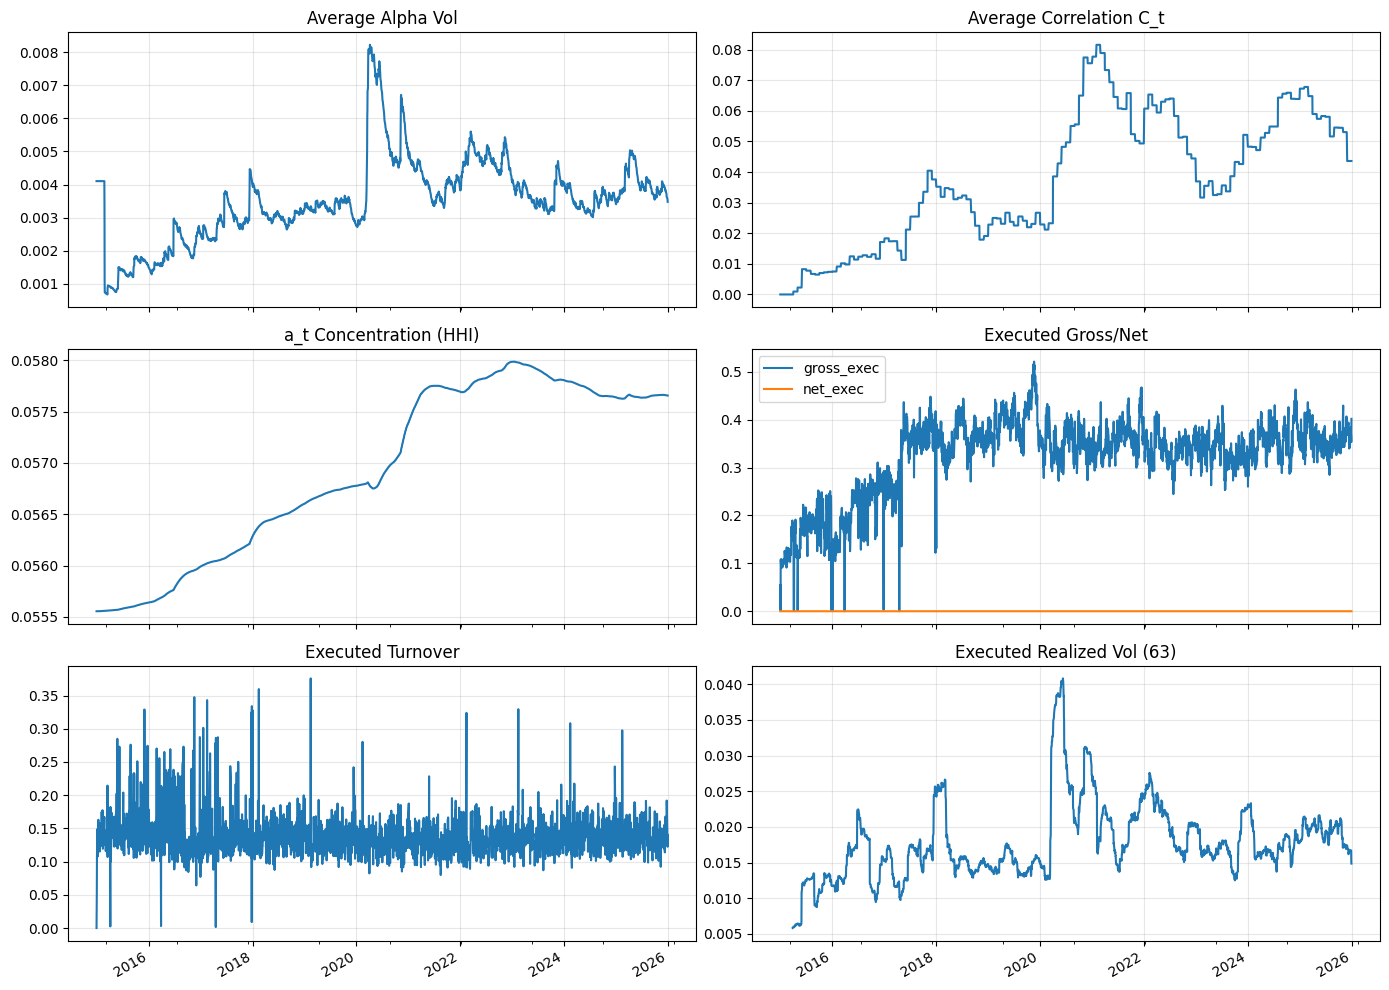

,alpha_vol_mean,avg_corr_C,a_concentration_hhi,gross_exec,net_exec,turnover_exec,tracking_error_pred,realized_pnl_exec,realized_vol_63
2025-12-23,0.003686,0.043608,0.057659,0.372278,7.009248e-07,0.131849,0.000263,0.000002,0.016713
2025-12-24,0.003625,0.043608,0.057659,0.384544,7.262392e-07,0.191884,0.000264,-0.000073,0.016712
2025-12-29,0.003575,0.043608,0.057658,0.366308,1.393233e-06,0.136978,0.000259,-0.000034,0.016719
2025-12-30,0.003530,0.043608,0.057658,0.353513,1.129715e-06,0.122333,0.000255,-0.000710,0.015074
2025-12-31,0.003477,0.043608,0.057657,0.401854,-4.892214e-08,0.140111,0.000252,0.000000,0.014867


In [13]:
# End-to-end pipeline (steps 2-6)
sigma_alpha = estimate_sigma_ewma(R_info, halflife=DEFAULTS["sigma_halflife"], min_periods=DEFAULTS["sigma_min_periods"])
R_scaled = R_info.div(sigma_alpha.replace(0.0, np.nan))
C_by_date, C_diag = estimate_C_shrunk(
    R_scaled,
    refresh=DEFAULTS["corr_refresh"],
    shrink=DEFAULTS["corr_shrink"],
    lookback=DEFAULTS["corr_lookback"],
    min_periods=DEFAULTS["corr_min_periods"],
)
Sigma_alpha_by_date, Sigma_diag = build_Sigma_alpha(sigma_alpha, C_by_date)

mu_alpha = estimate_mu(R_info, sigma_alpha, method=DEFAULTS["mu_method"], params=DEFAULTS["mu_params"])

a_t = solve_alpha_mvo(
    mu_alpha,
    Sigma_alpha_by_date,
    constraints=DEFAULTS["alpha_constraints"],
    hyperparams={
        "lambda_risk": DEFAULTS["lambda_risk"],
        "nu_ridge": DEFAULTS["nu_ridge"],
        "turnover_gamma": DEFAULTS["turnover_gamma"],
    },
)

w_hat = combine_alphas_to_weights(a_t, all_weights)

if instrument_fwd_returns is not None:
    inst_rets_info = instrument_fwd_returns.shift(1).reindex(index=w_hat.index, columns=w_hat.columns)
else:
    inst_rets_info = pd.DataFrame(0.0, index=w_hat.index, columns=w_hat.columns)

Omega_by_date = estimate_instrument_omega(
    inst_rets_info.fillna(0.0),
    method=DEFAULTS["omega_method"],
    halflife=DEFAULTS["omega_halflife"],
    lookback=DEFAULTS["omega_lookback"],
    min_periods=DEFAULTS["omega_min_periods"],
    shrink=DEFAULTS["omega_shrink"],
)

X_use = sector_exposure if "sector_exposure" in globals() else None
adv_use = adv_df if "adv_df" in globals() else None
w_exec, tracking_stats = run_tracking_optimizer(
    w_hat,
    Omega_by_date,
    costs=DEFAULTS["tracking_costs"],
    constraints=DEFAULTS["tracking_constraints"],
    X=X_use,
    adv_df=adv_use,
)

print("a_t shape:", a_t.shape)
print("w_hat shape:", w_hat.shape)
print("w_exec shape:", w_exec.shape)
display(a_t.head())
display(w_exec.head())
display(tracking_stats.head())


def validate_alignment(alpha_returns: pd.DataFrame, W_alpha: Dict[str, pd.DataFrame], fwd_ret: Optional[pd.DataFrame], atol: float = 1e-8) -> pd.Series:
    """No-lookahead check: R_k,t+1 == sum_i w_k,t * r_i,t+1."""
    if fwd_ret is None:
        warnings.warn("Skipping alignment check; no forward returns available.")
        return pd.Series(dtype=float)
    errs = {}
    for k in alpha_returns.columns:
        if k not in W_alpha:
            continue
        w = W_alpha[k]
        recon = (w * fwd_ret.reindex(index=w.index, columns=w.columns)).sum(axis=1)
        ref = alpha_returns[k].reindex(recon.index)
        d = (recon - ref).abs().dropna()
        errs[k] = float(d.max()) if len(d) else np.nan
    err_s = pd.Series(errs)
    if err_s.notna().any():
        assert float(err_s.max(skipna=True)) < atol, f"Alignment failed. Max error={err_s.max(skipna=True):.3e}"
    return err_s.sort_values()


alignment_err = validate_alignment(R_alpha, all_weights, instrument_fwd_returns)
min_eigs = pd.Series({dt: float(np.min(np.linalg.eigvalsh(0.5 * (S + S.T)))) for dt, S in Sigma_alpha_by_date.items()})
assert (min_eigs >= -1e-8).all(), "Sigma_alpha_t is not PSD within tolerance."
assert a_t.index.equals(w_hat.index)
assert w_hat.index.equals(w_exec.index)

if instrument_fwd_returns is not None:
    pnl_exec = (w_exec * instrument_fwd_returns.reindex(index=w_exec.index, columns=w_exec.columns)).sum(axis=1)
else:
    pnl_exec = pd.Series(0.0, index=w_exec.index)

summary = pd.DataFrame({
    "alpha_vol_mean": sigma_alpha.mean(axis=1),
    "avg_corr_C": C_diag["avg_corr"].reindex(sigma_alpha.index),
    "a_concentration_hhi": a_t.pow(2).sum(axis=1),
    "gross_exec": w_exec.abs().sum(axis=1),
    "net_exec": w_exec.sum(axis=1),
    "turnover_exec": w_exec.diff().abs().sum(axis=1).fillna(0.0),
    "tracking_error_pred": tracking_stats["tracking_error_pred"].reindex(w_exec.index),
    "realized_pnl_exec": pnl_exec,
})
summary["realized_vol_63"] = summary["realized_pnl_exec"].rolling(63).std() * np.sqrt(DEFAULTS["periods_per_year"])

print("Alignment max abs error:")
display(alignment_err.tail())
print("Sigma min eigenvalue summary:")
print(min_eigs.describe(percentiles=[0.01, 0.05, 0.5]))
print("Condition numbers (Sigma_alpha):")
print(Sigma_diag["cond_Sigma"].describe(percentiles=[0.5, 0.9, 0.99]))

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
summary["alpha_vol_mean"].plot(ax=axes[0, 0], title="Average Alpha Vol")
summary["avg_corr_C"].plot(ax=axes[0, 1], title="Average Correlation C_t")
summary["a_concentration_hhi"].plot(ax=axes[1, 0], title="a_t Concentration (HHI)")
summary[["gross_exec", "net_exec"]].plot(ax=axes[1, 1], title="Executed Gross/Net")
summary["turnover_exec"].plot(ax=axes[2, 0], title="Executed Turnover")
summary["realized_vol_63"].plot(ax=axes[2, 1], title="Executed Realized Vol (63)")
for ax in axes.ravel():
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
display(summary.tail())
